# Data Visualization Notebook

Python notebook to load data and generate common visualizations with Matplotlib and Seaborn.

This notebook is designed for CSV or Excel data. Run the cells in order.

In [ ]:
import sys
import subprocess

print('Active kernel Python:', sys.executable)

packages = ['pandas', 'numpy', 'matplotlib', 'seaborn']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pip'])
subprocess.check_call([sys.executable, '-m', 'pip', 'install', *packages])

print('Packages installed in the active notebook environment.')

Active kernel Python: c:\Users\ROGSTRIX\OneDrive\Desktop\SDU_MASTER_OFFICIAL\2nd_Semester\Engineering_Research_in_Software\Project\MAJJ-ADL-eris\.venv\Scripts\python.exe


## 1. Import Libraries and Configure Environment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global visual configuration
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

print('Libraries loaded and environment configured.')

Libraries loaded and environment configured.


## 2. Load Data from File

In [3]:
from pathlib import Path
import re

# Update this path based on your file
# Supports: .csv, .xlsx/.xls, and app-generated .txt files
DATA_PATH = Path('benchmark_results/ml_benchmark.txt')

def parse_benchmark_txt(path: Path) -> pd.DataFrame:
    text = path.read_text(encoding='utf-8', errors='ignore')
    patterns = {
        'preprocessing_ms': r'Preprocessing:\s*([0-9]+(?:\.[0-9]+)?)\s*ms',
        'model_load_ms': r'Model load:\s*([0-9]+(?:\.[0-9]+)?)\s*ms',
        'mean_ms': r'Mean:\s*([0-9]+(?:\.[0-9]+)?)\s*ms',
        'median_ms': r'Median:\s*([0-9]+(?:\.[0-9]+)?)\s*ms',
        'p95_ms': r'p95:\s*([0-9]+(?:\.[0-9]+)?)\s*ms',
        'stddev_ms': r'StdDev:\s*([0-9]+(?:\.[0-9]+)?)\s*ms',
        'runs': r'ML Benchmark\s*\((\d+)\s*runs\)'
    }

    row = {}
    for key, pattern in patterns.items():
        m = re.search(pattern, text, flags=re.IGNORECASE)
        row[key] = float(m.group(1)) if m else np.nan

    row['timestamp'] = pd.Timestamp.now()
    row['source_file'] = path.name
    return pd.DataFrame([row])

if DATA_PATH.suffix.lower() == '.csv':
    df = pd.read_csv(DATA_PATH)
elif DATA_PATH.suffix.lower() in ['.xlsx', '.xls']:
    df = pd.read_excel(DATA_PATH)
elif DATA_PATH.suffix.lower() == '.txt':
    df = parse_benchmark_txt(DATA_PATH)
else:
    raise ValueError(f'Unsupported format: {DATA_PATH.suffix}')

print(f'Data loaded from: {DATA_PATH}')
print(f'Shape: {df.shape}')
display(df.head())

required_example = ['timestamp', 'preprocessing_ms', 'model_load_ms', 'mean_ms', 'median_ms', 'p95_ms', 'stddev_ms']
print('Expected example columns:', required_example)
print('Current columns:', list(df.columns))

Data loaded from: benchmark_results\ml_benchmark.txt
Shape: (1, 9)


,preprocessing_ms,model_load_ms,mean_ms,median_ms,p95_ms,stddev_ms,runs,timestamp,source_file
0,1.35,5.41,3.94,1.39,17.52,7.23,100.0,2026-05-19 22:58:16.459332,ml_benchmark.txt


Expected example columns: ['timestamp', 'preprocessing_ms', 'model_load_ms', 'mean_ms', 'median_ms', 'p95_ms', 'stddev_ms']
Current columns: ['preprocessing_ms', 'model_load_ms', 'mean_ms', 'median_ms', 'p95_ms', 'stddev_ms', 'runs', 'timestamp', 'source_file']


## 3. Explore and Prepare Data for Plotting

In [4]:
# Safe working copy
work_df = df.copy()

print('Data types:')
display(work_df.dtypes)

print('Missing values per column:')
display(work_df.isna().sum())

print('Numeric statistics:')
display(work_df.describe(include='all'))

# Convert date if timestamp column exists
if 'timestamp' in work_df.columns:
    work_df['timestamp'] = pd.to_datetime(work_df['timestamp'], errors='coerce')
    work_df = work_df.sort_values('timestamp')

# Optional date filter example
if 'timestamp' in work_df.columns and work_df['timestamp'].notna().any():
    start_date = work_df['timestamp'].min()
    end_date = work_df['timestamp'].max()
    print(f'Detected time range: {start_date} -> {end_date}')

# Daily aggregation example
if 'timestamp' in work_df.columns and work_df['timestamp'].notna().any():
    numeric_cols = work_df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        daily_df = (
            work_df
            .set_index('timestamp')[numeric_cols]
            .resample('D')
            .mean()
            .reset_index()
        )
    else:
        daily_df = pd.DataFrame()
else:
    daily_df = pd.DataFrame()

print('Data prepared for plotting.')

Data types:


preprocessing_ms           float64
model_load_ms              float64
mean_ms                    float64
median_ms                  float64
p95_ms                     float64
stddev_ms                  float64
runs                       float64
timestamp           datetime64[us]
source_file                    str
dtype: object

Missing values per column:


preprocessing_ms    0
model_load_ms       0
mean_ms             0
median_ms           0
p95_ms              0
stddev_ms           0
runs                0
timestamp           0
source_file         0
dtype: int64

Numeric statistics:


,preprocessing_ms,model_load_ms,mean_ms,median_ms,p95_ms,stddev_ms,runs,timestamp,source_file
count,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1,1
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ml_benchmark.txt
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
mean,1.35,5.41,3.94,1.39,17.52,7.23,100.0,2026-05-19 22:58:16.459332,NaN
min,1.35,5.41,3.94,1.39,17.52,7.23,100.0,2026-05-19 22:58:16.459332,NaN
25%,1.35,5.41,3.94,1.39,17.52,7.23,100.0,2026-05-19 22:58:16.459332,NaN
50%,1.35,5.41,3.94,1.39,17.52,7.23,100.0,2026-05-19 22:58:16.459332,NaN
75%,1.35,5.41,3.94,1.39,17.52,7.23,100.0,2026-05-19 22:58:16.459332,NaN
max,1.35,5.41,3.94,1.39,17.52,7.23,100.0,2026-05-19 22:58:16.459332,NaN


Detected time range: 2026-05-19 22:58:16.459332 -> 2026-05-19 22:58:16.459332
Data prepared for plotting.


## 4. Create Line Charts

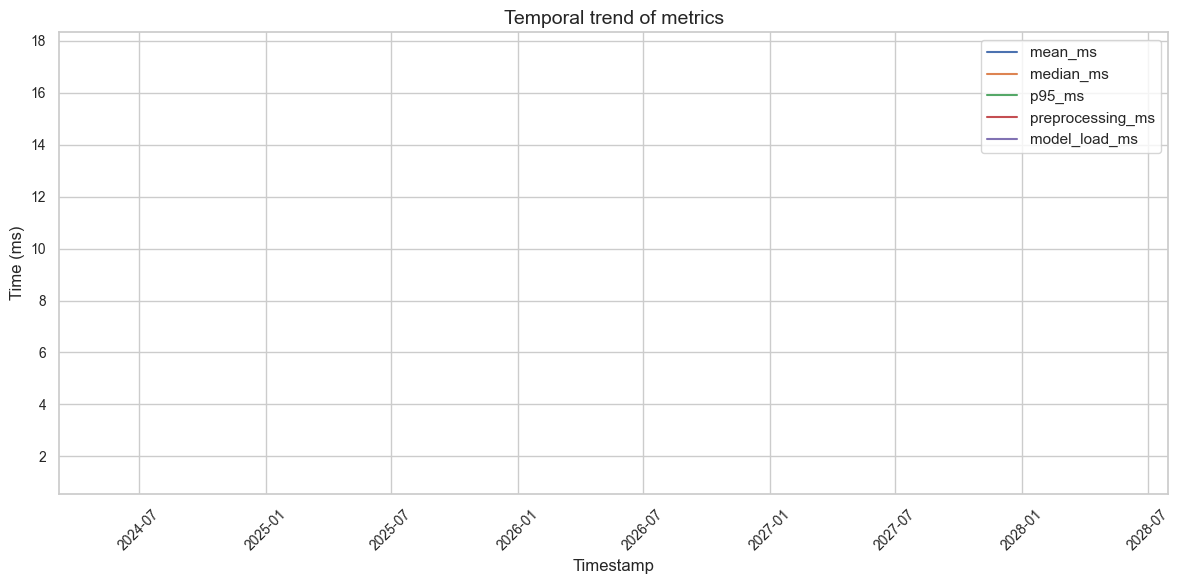

In [5]:
if 'timestamp' in work_df.columns and work_df['timestamp'].notna().any():
    # Select numeric columns for line plots
    line_cols = [c for c in ['mean_ms', 'median_ms', 'p95_ms', 'preprocessing_ms', 'model_load_ms'] if c in work_df.columns]

    if line_cols:
        plt.figure()
        for col in line_cols:
            sns.lineplot(data=work_df, x='timestamp', y=col, label=col)

        plt.title('Temporal trend of metrics')
        plt.xlabel('Timestamp')
        plt.ylabel('Time (ms)')
        plt.xticks(rotation=45)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print('No expected numeric columns found for line plot.')
else:
    print('No valid timestamp column found for line chart.')

## 5. Create Bar Charts

C:\Users\ROGSTRIX\AppData\Local\Temp\ipykernel_19736\2270764623.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=summary, x='metric', y='value_ms', palette='viridis')


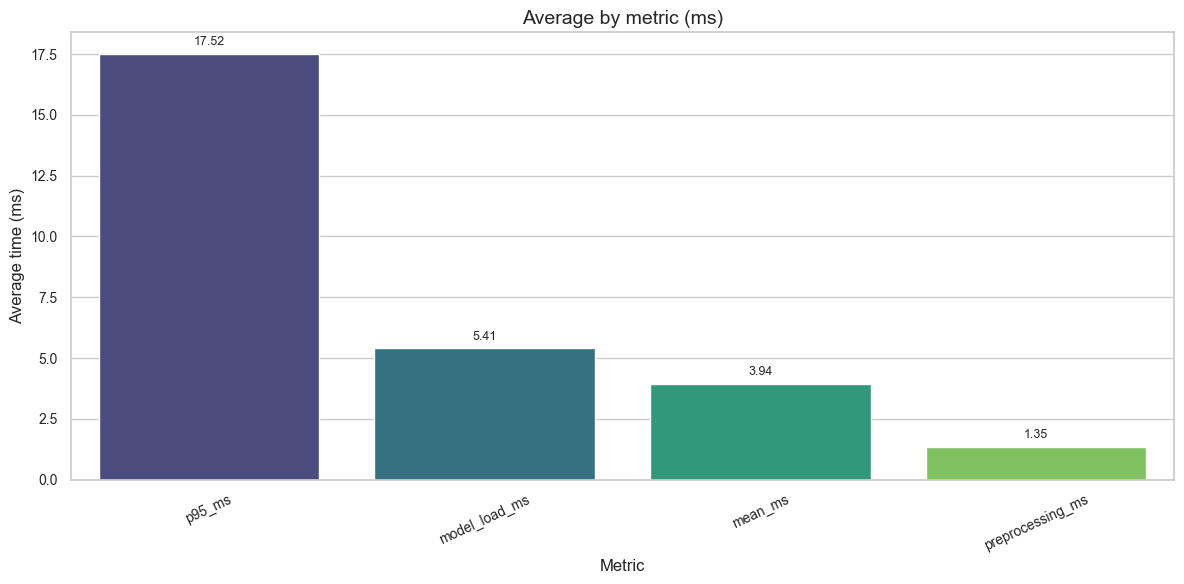

In [6]:
bar_cols = [c for c in ['preprocessing_ms', 'model_load_ms', 'mean_ms', 'p95_ms'] if c in work_df.columns]

if bar_cols:
    summary = work_df[bar_cols].mean().sort_values(ascending=False).reset_index()
    summary.columns = ['metric', 'value_ms']

    plt.figure()
    ax = sns.barplot(data=summary, x='metric', y='value_ms', palette='viridis')
    plt.title('Average by metric (ms)')
    plt.xlabel('Metric')
    plt.ylabel('Average time (ms)')
    plt.xticks(rotation=25)

    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f'{h:.2f}', (p.get_x() + p.get_width() / 2, h),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 4),
                    textcoords='offset points')

    plt.tight_layout()
    plt.show()
else:
    print('No expected columns found for bar chart.')

## 6. Create Histograms and Boxplots

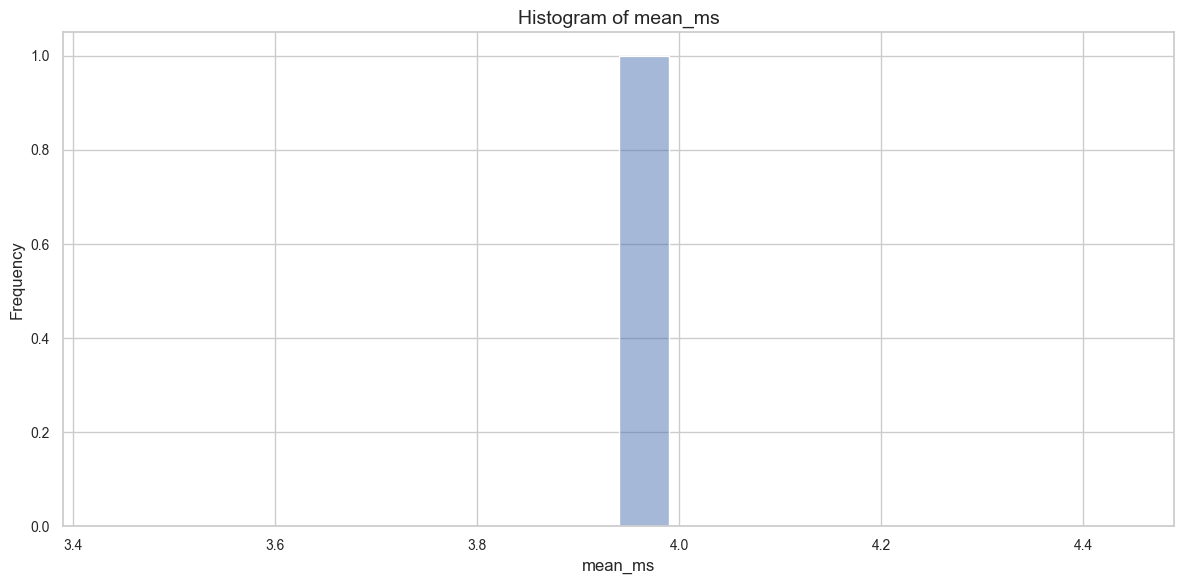

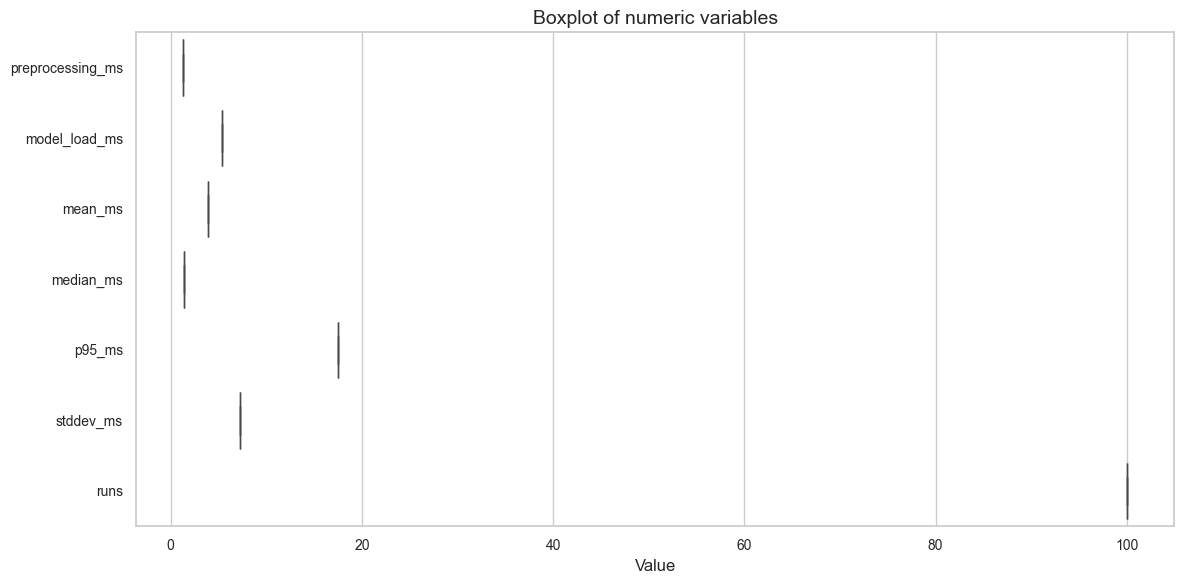

In [7]:
num_cols = work_df.select_dtypes(include=[np.number]).columns.tolist()

if num_cols:
    target_col = 'mean_ms' if 'mean_ms' in num_cols else num_cols[0]

    plt.figure()
    sns.histplot(work_df[target_col].dropna(), bins=20, kde=True)
    plt.title(f'Histogram of {target_col}')
    plt.xlabel(target_col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    plt.figure()
    sns.boxplot(data=work_df[num_cols], orient='h')
    plt.title('Boxplot of numeric variables')
    plt.xlabel('Value')
    plt.tight_layout()
    plt.show()
else:
    print('No numeric columns found for histograms and boxplots.')

## 7. Create Scatter Plots with Categories

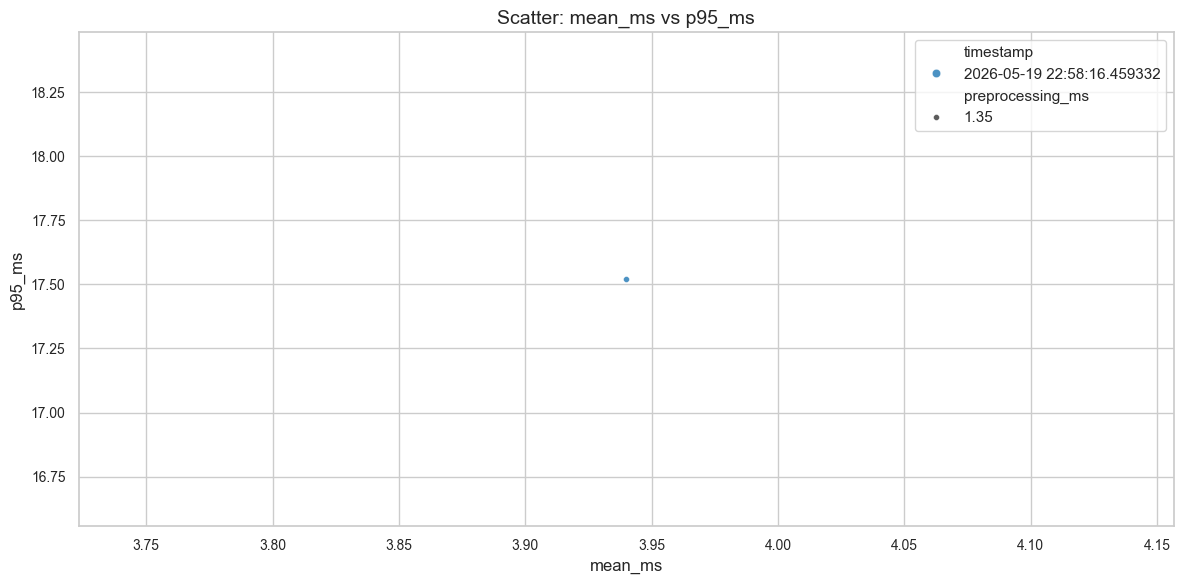

In [8]:
num_cols = work_df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = work_df.select_dtypes(exclude=[np.number]).columns.tolist()

if len(num_cols) >= 2:
    x_col = 'mean_ms' if 'mean_ms' in num_cols else num_cols[0]
    y_col = 'p95_ms' if 'p95_ms' in num_cols else num_cols[1]
    hue_col = 'device' if 'device' in work_df.columns else (cat_cols[0] if cat_cols else None)
    size_col = 'preprocessing_ms' if 'preprocessing_ms' in num_cols else None

    plt.figure()
    sns.scatterplot(
        data=work_df,
        x=x_col,
        y=y_col,
        hue=hue_col,
        size=size_col,
        palette='tab10',
        alpha=0.8
    )
    plt.title(f'Scatter: {x_col} vs {y_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for scatter plot.')

## 8. Customize and Save Charts

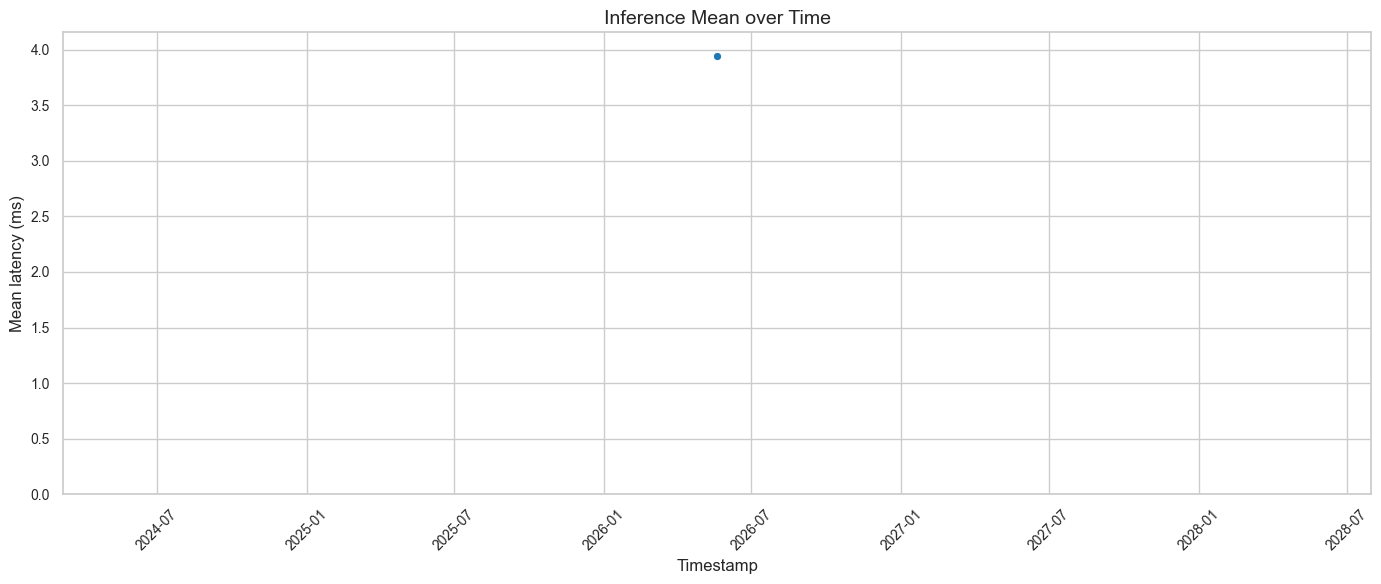

Charts saved at: benchmark_results\plots\inference_mean_over_time.png and benchmark_results\plots\inference_mean_over_time.svg


In [9]:
OUTPUT_DIR = Path('benchmark_results/plots')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Example of a customized final chart and export
if 'timestamp' in work_df.columns and 'mean_ms' in work_df.columns and work_df['timestamp'].notna().any():
    plt.figure(figsize=(14, 6))
    sns.lineplot(data=work_df, x='timestamp', y='mean_ms', marker='o', color='#1f77b4')
    plt.title('Inference Mean over Time')
    plt.xlabel('Timestamp')
    plt.ylabel('Mean latency (ms)')
    plt.xticks(rotation=45)
    plt.ylim(bottom=0)
    plt.tight_layout()

    png_path = OUTPUT_DIR / 'inference_mean_over_time.png'
    svg_path = OUTPUT_DIR / 'inference_mean_over_time.svg'
    plt.savefig(png_path, dpi=300, bbox_inches='tight')
    plt.savefig(svg_path, bbox_inches='tight')
    plt.show()

    print(f'Charts saved at: {png_path} and {svg_path}')
else:
    print('Could not generate final chart: missing timestamp/mean_ms columns.')

## 10. Carbon Footprint Accounting (Saved vs App Overhead)

This section estimates whether the app's own energy/emissions are lower than the emissions saved by delayed charging recommendations.

Core equation:

\[
\text{Net CO2e} = \text{CO2e saved by shifting charge} - \text{CO2e caused by running the app}
\]

If `net_co2e_g > 0`, the system is climate-positive in this scenario.

In [19]:
import numpy as np
import pandas as pd

# -----------------------------
# Editable assumptions (BASE)
# -----------------------------
scenario = {
    # User impact assumptions
    'shifted_energy_per_session_kwh': 20.0,      # kWh shifted by one delayed charging event
    'carbon_intensity_original_g_per_kwh': 240.0,
    'carbon_intensity_shifted_g_per_kwh': 120.0,
    'successful_shift_sessions_per_day': 50,

    # App operation assumptions
    'backend_average_power_w': 12.0,
    'backend_runtime_hours_per_day': 24.0,

    'mobile_active_power_w': 3.5,
    'mobile_active_seconds_per_session': 20.0,

    # Inference cost from benchmark (we will derive from df if possible)
    'fallback_inference_ms': 3.94,
    'inferences_per_session': 1,

    # Device power while doing one inference (phone/NPU or CPU estimate)
    'inference_device_power_w': 3.5,

    # Carbon intensity used for app-side electricity (cloud/device)
    'app_side_carbon_intensity_g_per_kwh': 160.0,
}

# Extract inference mean from parsed benchmark if available
inference_ms_from_benchmark = None
inference_source = 'fallback'
if 'mean_ms' in globals().get('df', pd.DataFrame()).columns:
    try:
        inference_ms_from_benchmark = float(pd.to_numeric(df['mean_ms'], errors='coerce').dropna().iloc[0])
    except Exception:
        inference_ms_from_benchmark = None

if inference_ms_from_benchmark is None:
    inference_ms_from_benchmark = scenario['fallback_inference_ms']
else:
    inference_source = 'benchmark mean_ms'

scenario['inference_ms'] = inference_ms_from_benchmark

per_inference_energy_wh = (
    scenario['inference_device_power_w'] * (scenario['inference_ms'] / 1000.0) / 3600.0
)
per_inference_energy_mwh = per_inference_energy_wh * 1000.0

print('Inference source:', inference_source)
print('inference_ms:', round(scenario['inference_ms'], 4))
print('Estimated per-inference energy (Wh):', per_inference_energy_wh)
print('Estimated per-inference energy (mWh):', per_inference_energy_mwh)
print('Edit the scenario dictionary to match your deployment assumptions.')

Inference source: fallback
inference_ms: 3.94
Estimated per-inference energy (Wh): 3.830555555555555e-06
Estimated per-inference energy (mWh): 0.0038305555555555554
Edit the scenario dictionary to match your deployment assumptions.


### 10.1 Device Profiling Note (Emulator vs Real Phone)

Android Studio emulator (`Medium Phone Android 14 x86_64`) runs on host CPU/GPU and does **not** represent real handset power draw.

Recommended reporting strategy:

1. Keep the emulator run-time benchmark (latency) as valid.
2. Report energy with **ranges** for `mobile_active_power_w` and `inference_device_power_w`.
3. Include at least one conservative profile and one realistic phone profile.

This notebook provides profile presets below so your conclusions remain transparent and reproducible.

In [20]:
# Profile presets to handle uncertainty when using emulator-only measurements
# Select one profile name and apply it to the scenario.

device_profiles = {
    # Host-powered emulator: not physical phone power; keep wider uncertainty
    'android_emulator_medium_phone_x86_64': {
        'mobile_active_power_w': 6.0,
        'inference_device_power_w': 6.0,
        'profile_note': 'Emulator-on-host proxy. High uncertainty.'
    },
    # Typical mid-range smartphone active usage estimate
    'physical_midrange_phone': {
        'mobile_active_power_w': 3.0,
        'inference_device_power_w': 2.5,
        'profile_note': 'Approximate real device profile (literature-style estimate).'
    },
    # Conservative high-power phone-side estimate
    'physical_phone_conservative_high': {
        'mobile_active_power_w': 5.0,
        'inference_device_power_w': 4.0,
        'profile_note': 'Conservative upper-bound estimate.'
    },
}

selected_profile = 'android_emulator_medium_phone_x86_64'
scenario.update(device_profiles[selected_profile])

print('Selected profile:', selected_profile)
print('Profile note:', scenario['profile_note'])
print('mobile_active_power_w =', scenario['mobile_active_power_w'])
print('inference_device_power_w =', scenario['inference_device_power_w'])

Selected profile: android_emulator_medium_phone_x86_64
Profile note: Emulator-on-host proxy. High uncertainty.
mobile_active_power_w = 6.0
inference_device_power_w = 6.0


In [21]:
# Quick uncertainty sweep around selected profile (+/- 30%)
# Useful when only emulator is available.

if 'estimate_daily_impact' not in globals():
    def estimate_daily_impact(s):
        sessions = float(s['successful_shift_sessions_per_day'])
        delta_ci = float(s['carbon_intensity_original_g_per_kwh']) - float(s['carbon_intensity_shifted_g_per_kwh'])
        saved_g_per_session = float(s['shifted_energy_per_session_kwh']) * max(delta_ci, 0.0)
        saved_g_per_day = sessions * saved_g_per_session

        backend_kwh_day = (float(s['backend_average_power_w']) * float(s['backend_runtime_hours_per_day'])) / 1000.0
        mobile_kwh_day = (
            float(s['mobile_active_power_w'])
            * float(s['mobile_active_seconds_per_session'])
            * sessions
        ) / (1000.0 * 3600.0)
        inference_kwh_day = (
            float(s['inference_device_power_w'])
            * (float(s['inference_ms']) / 1000.0)
            * float(s['inferences_per_session'])
            * sessions
        ) / (1000.0 * 3600.0)

        app_kwh_day = backend_kwh_day + mobile_kwh_day + inference_kwh_day
        app_g_per_day = app_kwh_day * float(s['app_side_carbon_intensity_g_per_kwh'])
        net_g_per_day = saved_g_per_day - app_g_per_day
        ratio = saved_g_per_day / app_g_per_day if app_g_per_day > 0 else np.inf

        return {
            'sessions_per_day': sessions,
            'saved_g_per_day': saved_g_per_day,
            'app_g_per_day': app_g_per_day,
            'net_g_per_day': net_g_per_day,
            'saved_kg_per_month': (saved_g_per_day * 30.0) / 1000.0,
            'app_kg_per_month': (app_g_per_day * 30.0) / 1000.0,
            'net_kg_per_month': (net_g_per_day * 30.0) / 1000.0,
            'benefit_cost_ratio': ratio,
            'backend_kwh_day': backend_kwh_day,
            'mobile_kwh_day': mobile_kwh_day,
            'inference_kwh_day': inference_kwh_day,
            'app_kwh_day': app_kwh_day,
        }

u = 0.30
base_mobile = scenario['mobile_active_power_w']
base_infer = scenario['inference_device_power_w']

uncertainty_cases = {
    'low_power_bound': {
        **scenario,
        'mobile_active_power_w': base_mobile * (1 - u),
        'inference_device_power_w': base_infer * (1 - u),
    },
    'base_power': {
        **scenario,
    },
    'high_power_bound': {
        **scenario,
        'mobile_active_power_w': base_mobile * (1 + u),
        'inference_device_power_w': base_infer * (1 + u),
    },
}

unc_rows = []
for n, cfg in uncertainty_cases.items():
    r = estimate_daily_impact(cfg)
    unc_rows.append({
        'power_case': n,
        'saved_g_per_day': r['saved_g_per_day'],
        'app_g_per_day': r['app_g_per_day'],
        'net_g_per_day': r['net_g_per_day'],
        'benefit_cost_ratio': r['benefit_cost_ratio'],
    })

display(pd.DataFrame(unc_rows))

,power_case,saved_g_per_day,app_g_per_day,net_g_per_day,benefit_cost_ratio
0,low_power_bound,120000.0,46.266703,119953.733297,2593.657881
1,base_power,120000.0,46.346719,119953.653281,2589.180034
2,high_power_bound,120000.0,46.426735,119953.573265,2584.717622


In [22]:
def estimate_daily_impact(s):
    sessions = float(s['successful_shift_sessions_per_day'])

    # 1) Emissions saved by shifting charging time
    delta_ci = float(s['carbon_intensity_original_g_per_kwh']) - float(s['carbon_intensity_shifted_g_per_kwh'])
    saved_g_per_session = float(s['shifted_energy_per_session_kwh']) * max(delta_ci, 0.0)
    saved_g_per_day = sessions * saved_g_per_session

    # 2) App-side energy (kWh/day)
    backend_kwh_day = (float(s['backend_average_power_w']) * float(s['backend_runtime_hours_per_day'])) / 1000.0

    mobile_kwh_day = (
        float(s['mobile_active_power_w'])
        * float(s['mobile_active_seconds_per_session'])
        * sessions
    ) / (1000.0 * 3600.0)

    inference_kwh_day = (
        float(s['inference_device_power_w'])
        * (float(s['inference_ms']) / 1000.0)
        * float(s['inferences_per_session'])
        * sessions
    ) / (1000.0 * 3600.0)

    app_kwh_day = backend_kwh_day + mobile_kwh_day + inference_kwh_day

    # 3) App-side emissions
    app_g_per_day = app_kwh_day * float(s['app_side_carbon_intensity_g_per_kwh'])

    # 4) Net climate impact
    net_g_per_day = saved_g_per_day - app_g_per_day
    ratio = saved_g_per_day / app_g_per_day if app_g_per_day > 0 else np.inf

    return {
        'sessions_per_day': sessions,
        'saved_g_per_day': saved_g_per_day,
        'app_g_per_day': app_g_per_day,
        'net_g_per_day': net_g_per_day,
        'saved_kg_per_month': (saved_g_per_day * 30.0) / 1000.0,
        'app_kg_per_month': (app_g_per_day * 30.0) / 1000.0,
        'net_kg_per_month': (net_g_per_day * 30.0) / 1000.0,
        'benefit_cost_ratio': ratio,
        'backend_kwh_day': backend_kwh_day,
        'mobile_kwh_day': mobile_kwh_day,
        'inference_kwh_day': inference_kwh_day,
        'app_kwh_day': app_kwh_day,
    }

base_result = estimate_daily_impact(scenario)
pd.DataFrame([base_result]).T.rename(columns={0: 'value'})

,value
sessions_per_day,5.000000e+01
saved_g_per_day,1.200000e+05
app_g_per_day,4.634672e+01
net_g_per_day,1.199537e+05
saved_kg_per_month,3.600000e+03
app_kg_per_month,1.390402e+00
net_kg_per_month,3.598610e+03
benefit_cost_ratio,2.589180e+03
backend_kwh_day,2.880000e-01
mobile_kwh_day,1.666667e-03


In [23]:
# Sensitivity analysis: conservative/base/optimistic

if 'estimate_daily_impact' not in globals():
    def estimate_daily_impact(s):
        sessions = float(s['successful_shift_sessions_per_day'])
        delta_ci = float(s['carbon_intensity_original_g_per_kwh']) - float(s['carbon_intensity_shifted_g_per_kwh'])
        saved_g_per_session = float(s['shifted_energy_per_session_kwh']) * max(delta_ci, 0.0)
        saved_g_per_day = sessions * saved_g_per_session

        backend_kwh_day = (float(s['backend_average_power_w']) * float(s['backend_runtime_hours_per_day'])) / 1000.0
        mobile_kwh_day = (
            float(s['mobile_active_power_w'])
            * float(s['mobile_active_seconds_per_session'])
            * sessions
        ) / (1000.0 * 3600.0)
        inference_kwh_day = (
            float(s['inference_device_power_w'])
            * (float(s['inference_ms']) / 1000.0)
            * float(s['inferences_per_session'])
            * sessions
        ) / (1000.0 * 3600.0)

        app_kwh_day = backend_kwh_day + mobile_kwh_day + inference_kwh_day
        app_g_per_day = app_kwh_day * float(s['app_side_carbon_intensity_g_per_kwh'])
        net_g_per_day = saved_g_per_day - app_g_per_day
        ratio = saved_g_per_day / app_g_per_day if app_g_per_day > 0 else np.inf

        return {
            'sessions_per_day': sessions,
            'saved_g_per_day': saved_g_per_day,
            'app_g_per_day': app_g_per_day,
            'net_g_per_day': net_g_per_day,
            'saved_kg_per_month': (saved_g_per_day * 30.0) / 1000.0,
            'app_kg_per_month': (app_g_per_day * 30.0) / 1000.0,
            'net_kg_per_month': (net_g_per_day * 30.0) / 1000.0,
            'benefit_cost_ratio': ratio,
            'backend_kwh_day': backend_kwh_day,
            'mobile_kwh_day': mobile_kwh_day,
            'inference_kwh_day': inference_kwh_day,
            'app_kwh_day': app_kwh_day,
        }

cases = {
    'conservative': {
        **scenario,
        'successful_shift_sessions_per_day': 20,
        'carbon_intensity_original_g_per_kwh': 200,
        'carbon_intensity_shifted_g_per_kwh': 150,
    },
    'base': {
        **scenario,
    },
    'optimistic': {
        **scenario,
        'successful_shift_sessions_per_day': 120,
        'carbon_intensity_original_g_per_kwh': 300,
        'carbon_intensity_shifted_g_per_kwh': 100,
    },
}

rows = []
for name, cfg in cases.items():
    out = estimate_daily_impact(cfg)
    out['case'] = name
    rows.append(out)

sens_df = pd.DataFrame(rows)[[
    'case',
    'sessions_per_day',
    'saved_g_per_day',
    'app_g_per_day',
    'net_g_per_day',
    'benefit_cost_ratio',
    'saved_kg_per_month',
    'app_kg_per_month',
    'net_kg_per_month',
]]

sens_df

,case,sessions_per_day,saved_g_per_day,app_g_per_day,net_g_per_day,benefit_cost_ratio,saved_kg_per_month,app_kg_per_month,net_kg_per_month
0,conservative,20.0,20000.0,46.186688,19953.813312,433.025207,600.0,1.385601,598.614399
1,base,50.0,120000.0,46.346719,119953.653281,2589.180034,3600.0,1.390402,3598.609598
2,optimistic,120.0,480000.0,46.720126,479953.279874,10273.944877,14400.0,1.401604,14398.598396


In [24]:
def report_sentence(r):
    verdict = 'climate-positive' if r['net_g_per_day'] > 0 else 'not climate-positive'
    return (
        f"Daily saved CO2e: {r['saved_g_per_day']:.1f} g; "
        f"daily app CO2e: {r['app_g_per_day']:.1f} g; "
        f"net: {r['net_g_per_day']:.1f} g/day "
        f"(ratio saved/app = {r['benefit_cost_ratio']:.2f}). "
        f"Conclusion: {verdict}."
    )

print('Base-case summary for report:')
print(report_sentence(base_result))

Base-case summary for report:
Daily saved CO2e: 120000.0 g; daily app CO2e: 46.3 g; net: 119953.7 g/day (ratio saved/app = 2589.18). Conclusion: climate-positive.
